#### All Imports

In [68]:
import os
from langgraph.graph import StateGraph, END, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing_extensions import TypedDict, Literal, Annotated
from langchain.messages import HumanMessage, SystemMessage, AnyMessage
from langgraph.graph.message import add_messages
from langchain.tools import tool
from tavily import TavilyClient
from pydantic import BaseModel, Field
from pprint import pprint
from IPython.display import Markdown, display, Image
from langgraph.prebuilt import ToolNode

In [69]:
load_dotenv(".env")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [70]:
basic_llm = ChatGroq(model="llama-3.1-8b-instant", api_key = GROQ_API_KEY, temperature=0)
advanced_llm = ChatGroq(model="llama-3.1-8b-instant", api_key = GROQ_API_KEY, temperature=0)

In [71]:
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

In [72]:
# Prompts - Read Content from Files
f = open("./prompts/generations.md")
GENERATION_PROMPT = f.read()
f = open("./prompts/optimisation.md")
OPTIMISATION_PROMPT = f.read()
f = open("./prompts/scoring.md")
SCORING_PROMPT = f.read()
f = open("./prompts/validation.md")
VALIDATION_PROMPT = f.read()

In [73]:
class MarketingState(TypedDict):
    user_input: str
    customer_data: str
    score: str
    offer: str
    feedback: str
    optimized_offre: str
    next: Literal["START", "FETCHING", "SCORING", "GENERATION", "VALIDATION", "OPTIMISATION", "END"]
    messages: Annotated[list[AnyMessage], add_messages]

#### Scoring Agent

In [74]:
customer_data = """
        I have a client who spent 10 dollars on online shopping products during the last month.
        The client made 3 purchases, mainly buying electronics and accessories.
        Their average order value is around 3.33 dollars, and they usually purchase during weekends.
        The client has been active for 6 months and shows moderate engagement with marketing campaigns.
"""

def scoring_agent(state: MarketingState):
    print("Scoring Agent ...")
    customer_data = state.get("customer_data")
    messages = [HumanMessage(content=f"Customer Data: {customer_data}"), SystemMessage(content=SCORING_PROMPT)]
    score = basic_llm.invoke(messages)

    return {
        "score": score,
        "next": "GENERATION",
    }



In [75]:
# Test Scroing Agent
state: MarketingState = {
    "user_input": "Generate Marketing Offre based on the customer data",
    "client_data": customer_data,
    "offre": None,
    "score": 0,
}
result = scoring_agent(state)
display(Markdown(result.get("score").content))

Scoring Agent ...


**Score**: 100 / 100
**Policy Compliance**: NO POLICY
**Areas for Improvement**: None

#### Generation Agent

In [76]:
@tool("HowToWriteMarketingOffre")
def HowToWriteMarketingOffre(query: str, limit: int) -> list:
    """
        Search On Internet Using Of How to Write Marketing Offre
        Args:
            query: Search term to look for
            limit: Maximum number of results to return
    """
    response = tavily_client.search(query=query, max_results=limit)
    results = response.get("results", [])
    content = []
    for res in results:
        content.append({"url": res.get("url", ""), "content": res.get("content", "")})
    return content

# Generation Agent
def generation_agent(state: MarketingState):
    print("Generation Agent ...")
    customer_data = state.get("client_data", "No Client Data")
    customer_score = state.get("score", "0")
    user_input = state.get('user_input', "Generate Marketing Offre based on the customer data")
    messages = [
        SystemMessage(content=GENERATION_PROMPT),
        HumanMessage(
            content=f"""
            Generate marketing offer.

            User Request:
            {user_input}

            Customer Data:
            {customer_data}
            
            Customer Score:
            {customer_score}/100
            """
        )
    ]
    offre = basic_llm.invoke(messages)
    return {
        "offre": offre,
        "next": "VALIDATION"
    }



In [77]:
# Test Generation Agent
state: MarketingState = {
    "user_input": "Generate Marketing Offre based on the customer data",
    "client_data": customer_data,
    "offre": None,
    "score": 0,
}
result = generation_agent(state)
# display(Markdown(result.get("offre").content))

Generation Agent ...


#### Validation Agent

In [78]:
rules = "no rules"
# Validation Agent
def validation_agent(state: MarketingState):
    print("Validation Agent ...")
    # Get Offre
    offre = state.get("offre", "no offre")
    messages = [SystemMessage(content=VALIDATION_PROMPT), HumanMessage(content=
        f"""
        Offre: \n\n
            {offre}
        Rules: \n\n
            {rules}
        """
    )]

    response = basic_llm.invoke(messages)
    return {"feedback": response, "next": "OPTIMISATION"}


In [79]:
# Test Validation Agent
offre = """Bonjour Ahmed,
Nous sommes ravis de vous proposer une offre spéciale en votre nom !
Vous avez déjà dépensé 209,70€ chez nous
Nous avons remarqué que vous avez acheté des produits de qualité tels que des parfums, des chaussures et des t-shirts. Nous sommes convaincus que vous allez adorer notre nouvelle collection de produits de luxe !
Découvrez nos meilleures offres
Parfum exclusif : 50% de réduction sur notre nouveau parfum, disponible uniquement pendant une semaine !
Chaussures de luxe : 30% de réduction sur nos chaussures de luxe, conçues pour les pieds les plus exigeants !
T-shirt premium : 20% de réduction sur nos t-shirts premium, faits avec les matériaux les plus confortables !
N'oubliez pas de profiter de nos offres spéciales
Livraison gratuite : sur tous les commandes supérieures à 100€
Retour gratuit : sur tous les produits achetés chez nous
Cliquez ici pour découvrir nos offres [lien vers la page d'offres]
Nous sommes impatients de vous voir chez nous !
Cordialement, L'équipe de [votre nom de l'entreprise]
"""
# Test Validation Agent
state: MarketingState = {
    "offre": offre,
    "user_input": "Generate Marketing Offre based on the customer data",
    "client_data": customer_data,
    "offre": None,
    "score": 0,
}
result = validation_agent(state)
result
# display(Markdown(result.get("offre").content))

Validation Agent ...


{'feedback': AIMessage(content='**Validation Result:** \nThe offer is **valid** since no business rules are provided or retrieved.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 114, 'total_tokens': 135, 'completion_time': 0.038171866, 'completion_tokens_details': None, 'prompt_time': 0.00694853, 'prompt_tokens_details': None, 'queue_time': 0.01776011, 'total_time': 0.045120396}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_6a1eabf260', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fdbdf-0124-7bf3-acaa-9aed4b12990e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 114, 'output_tokens': 21, 'total_tokens': 135}),
 'next': 'OPTIMISATION'}

#### Optimisation Offre

In [80]:
# Agent for offre Optimisation
def optmisation_agent(state: MarketingState):
    print("Optimisation Agent ...")
    feedback = state.get("feedback", "no feedback")
    offre = state.get("offre", "None")
    messages = [SystemMessage(content=OPTIMISATION_PROMPT), HumanMessage(content=f"""
        Based on This feedback: \n\n
            {feedback}
        Optimise this Offre: \n\n 
            {offre}
        """)]
    
    response = basic_llm.invoke(messages)
    return {"optimized_offre": response, "next": "END"}


In [81]:
# Test Validation Agent
offre = """Bonjour Ahmed,
Nous sommes ravis de vous proposer une offre spéciale en votre nom !
Vous avez déjà dépensé 209,70€ chez nous
Nous avons remarqué que vous avez acheté des produits de qualité tels que des parfums, des chaussures et des t-shirts. Nous sommes convaincus que vous allez adorer notre nouvelle collection de produits de luxe !
Découvrez nos meilleures offres
Parfum exclusif : 50% de réduction sur notre nouveau parfum, disponible uniquement pendant une semaine !
Chaussures de luxe : 30% de réduction sur nos chaussures de luxe, conçues pour les pieds les plus exigeants !
T-shirt premium : 20% de réduction sur nos t-shirts premium, faits avec les matériaux les plus confortables !
N'oubliez pas de profiter de nos offres spéciales
Livraison gratuite : sur tous les commandes supérieures à 100€
Retour gratuit : sur tous les produits achetés chez nous
Cliquez ici pour découvrir nos offres [lien vers la page d'offres]
Nous sommes impatients de vous voir chez nous !
Cordialement, L'équipe de [votre nom de l'entreprise]
"""
# Test Validation Agent
state: MarketingState = {
    "offre": offre,
    "user_input": "Generate Marketing Offre based on the customer data",
    "client_data": customer_data,
    "offre": None,
    "score": 0,
}
result = optmisation_agent(state)
result
# display(Markdown(result.get("offre").content))

Optimisation Agent ...


{'optimized_offre': AIMessage(content="**Improved Offer**\n\nGet Exclusive Access to Our Premium Services\n\nJoin our community today and unlock a world of benefits, including:\n\n* Priority customer support\n* Early access to new features and updates\n* Personalized recommendations tailored to your needs\n* Exclusive discounts and promotions\n\nAs a valued member, you'll enjoy a seamless and personalized experience that meets your unique requirements. Don't miss out on this opportunity to elevate your experience with us. Sign up now and discover the difference for yourself.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 98, 'prompt_tokens': 156, 'total_tokens': 254, 'completion_time': 0.150473939, 'completion_tokens_details': None, 'prompt_time': 0.008601293, 'prompt_tokens_details': None, 'queue_time': 0.048820722, 'total_time': 0.159075232}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4848f70c04', 'service_tier': 'on_demand', 'fin

#### Supervisor Agent

In [82]:
# Supervisor agent
def supervisor_agent(state: MarketingState):
    print("Supervisor Agent ...")
    return state

#### Build graph

In [83]:
def routerForSupervisor(state: MarketingState):
    return state.get("next", "END")

In [84]:
workflow = StateGraph(MarketingState)

In [ ]:
workflow.add_node("supervisor_agent", supervisor_agent)
workflow.add_node("scoring_agent", scoring_agent)

workflow.add_edge("scoring_agent", "supervisor_agent")

workflow.add_node("generation_agent", generation_agent)
workflow.add_edge("generation_agent", "supervisor_agent")


workflow.add_node("validation_agent", validation_agent)
workflow.add_edge("validation_agent", "supervisor_agent")


workflow.add_node("optmisation_agent", optmisation_agent)
workflow.add_edge("optmisation_agent", "supervisor_agent")


workflow.set_entry_point("supervisor_agent")
workflow.add_conditional_edges("supervisor_agent", routerForSupervisor, 
    {
        "SCORING": "scoring_agent",
        "GENERATION": "generation_agent",
        "VALIDATION": "validation_agent",
        "OPTIMISATION": "optmisation_agent",
        "END": END
    }
)


In [86]:
app = workflow.compile()

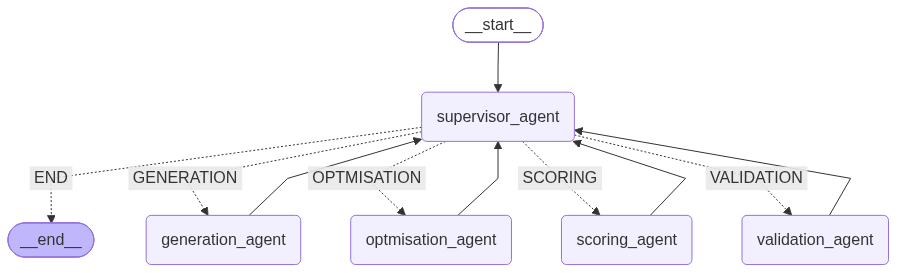

In [87]:
display(Image(app.get_graph().draw_mermaid_png()))

In [88]:
# Test Validation Agent
state: MarketingState = {
    "offre": offre,
    "user_input": "Generate Marketing Offre based on the customer data",
    "client_data": customer_data,
    "offre": None,
    "score": 0,
    "next": "SCORING"
}
final_state = app.invoke(state)
final_state


Supervisor Agent ...
Scoring Agent ...
Supervisor Agent ...
Generation Agent ...
Supervisor Agent ...
Validation Agent ...
Supervisor Agent ...


KeyError: 'OPTIMISATION'